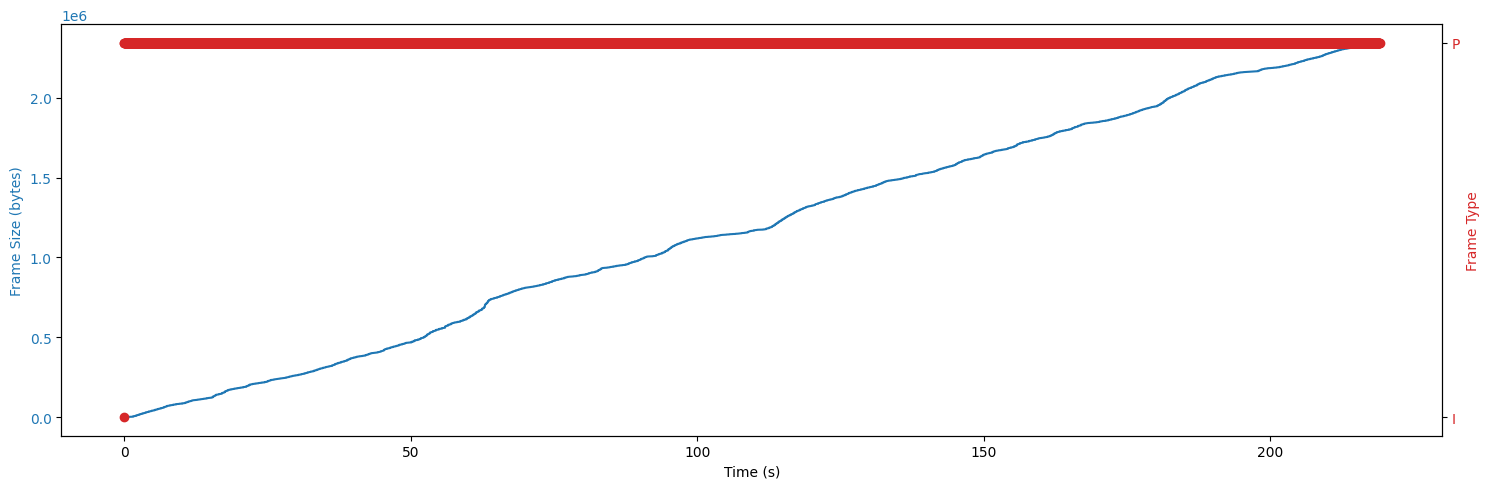

In [1]:
import subprocess
import json
import matplotlib.pyplot as plt

# Extract frame information using ffprobe
cmd = [
    "ffprobe",
    "-show_frames",
    "-print_format",
    "json",
    "-select_streams",
    "v",
    "terribleapple4.webm",
]
result = subprocess.run(cmd, capture_output=True, text=True)
frames = json.loads(result.stdout)['frames']

# Parse frame types and timestamps
frame_types = [frame['pict_type'] for frame in frames]
timestamps = [float(frame['pts_time']) for frame in frames]
frame_sizes = [int(frame['pkt_size']) for frame in frames if 'pkt_size' in frame]
cumulative_sizes = [sum(frame_sizes[:i+1]) for i in range(len(frame_sizes))]

# Step 3: Plot frame types and sizes over time
fig, ax1 = plt.subplots(figsize=(15, 5))

color = 'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Frame Size (bytes)', color=color)
ax1.plot(timestamps, cumulative_sizes, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Frame Type', color=color)
ax2.plot(timestamps, frame_types, 'o', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()